# Comprehensive Business Analytics Project: Sustainable Fashion Data Analysis
**Module**: BUSI 1783 - Business Analytics Project  
**Author**: Quantitative Research Group  
**Dataset**: `Untitled form Coded.xlsx` (N = 200 respondents, 26 items)  

---

## Executive Summary & Analytical Scope
This Jupyter Notebook executes the complete quantitative data analysis pipeline for the **Sustainable Fashion Consumer Study**.
The objective is to evaluate consumer awareness, brand skepticism, personal values, eco-label trust, perceived barriers, purchase intentions, and willingness to pay premium.

The notebook is organized into 6 core statistical modules:
1. **Frequency Distribution Analysis**: Profile of respondents (Demographics & Likert item distributions).
2. **Descriptive Statistics**: Central tendency, dispersion, skewness, and kurtosis across items and construct dimensions.
3. **Reliability Analysis**: Internal consistency evaluation using Cronbach's Alpha ($lpha$) and item-total correlations.
4. **Correlation Analysis**: Pearson bivariate correlation matrix, Spearman rank correlation, and heatmaps.
5. **Multiple Linear Regression Analysis**: Predictive models for Purchase Intention ($PI$) and Willingness to Pay Premium ($WTP$) with full residual diagnostics and VIF multicollinearity checks.
6. **Chi-Square Test of Independence**: Bivariate cross-tabulations ($\chi^2$), p-values, and Cramér's V effect size testing between demographic segments and sustainable behaviors.


---
## Section 1: Environment Setup & Data Ingestion

### Code Explanation:
In this section, we import key Python packages required for statistical computing:
- `pandas` & `numpy`: Data manipulation, aggregation, and mathematical operations.
- `scipy.stats`: Hypotheses testing, chi-square contingency, and distributional metrics.
- `statsmodels.api`: Ordinary Least Squares (OLS) regression and VIF diagnostics.
- `matplotlib.pyplot` & `seaborn`: High-resolution data visualizations.

We load the dataset directly from `Untitled form Coded.xlsx` (specifically the `Coded File` sheet containing numerical Likert scores 1–5 and coded demographics). We also construct mean composite scores for the 7 underlying theoretical constructs.


In [16]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Data path
excel_path = "/content/Untitled form Coded.xlsx"
df = pd.read_excel(excel_path, sheet_name='Coded File')

print(f"Dataset successfully loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

# Define Construct Mappings
constructs = {
    'Environmental_Awareness': [
        'I understand the environmental impact of fashion products.',
        'I consider sustainability when buying fashion products.',
        'I believe consumers should support sustainable fashion.'
    ],
    'Brand_Skepticism': [
        'I question sustainability claims made by fashion brands.',
        'I believe some fashion brands exaggerate their green claims.',
        'I look for evidence before trusting sustainability statements.'
    ],
    'Personal_Values': [
        'Sustainable fashion reflects my personal values.',
        'I use fashion choices to express my identity.',
        'I feel connected with people who support sustainable fashion.'
    ],
    'Ecolabel_Trust': [
        'I trust eco-labels on sustainable fashion products.',
        'I believe certified eco-labels provide reliable information.',
        'Eco-labels help me choose sustainable fashion products.'
    ],
    'Perceived_Barriers': [
        'The price of sustainable fashion affects my buying decisions.',
        'Limited availability makes it difficult to buy sustainable fashion.',
        'Style choices influence my decision to buy sustainable fashion.'
    ],
    'Purchase_Intention': [
        'I regularly buy sustainable fashion products.',
        'I choose sustainable fashion brands when available.',
        'I intend to continue purchasing sustainable fashion products.'
    ],
    'Willingness_To_Pay': [
        'I am willing to pay more for sustainable fashion products.',
        'I accept higher prices for environmentally friendly clothing.',
        'I would choose sustainable fashion even if it costs more.'
    ]
}

# Create Composite Construct Columns (Mean scores)
comp_df = pd.DataFrame()
for c_name, items in constructs.items():
    comp_df[c_name] = df[items].mean(axis=1)

# Display preview of dataset
comp_df.head()


Dataset successfully loaded. Shape: 200 rows, 26 columns.


,Environmental_Awareness,Brand_Skepticism,Personal_Values,Ecolabel_Trust,Perceived_Barriers,Purchase_Intention,Willingness_To_Pay
0,5.000000,3.666667,3.000000,3.333333,3.333333,3.333333,4.000000
1,4.333333,4.333333,3.000000,5.000000,4.000000,4.000000,3.000000
2,4.333333,3.000000,5.000000,3.333333,5.000000,3.666667,4.000000
3,4.000000,4.000000,3.666667,3.666667,3.333333,3.666667,3.333333
4,3.666667,5.000000,4.666667,3.333333,3.666667,4.000000,3.000000


---
## Section 2: Frequency Distribution Analysis

### Code Explanation:
Frequency distribution analysis summarizes the categorical demographic attributes of respondents.
We map coded numeric values back to readable labels for:
- **Age Group** (18-24, 25-34, 35-44, 45-54, 55+)
- **Gender** (Male, Female, Prefer not to say)
- **Monthly Income** (<£1k, £1k-£2k, £2k-£3k, £3k-£4k, £4k+, Prefer not to say)
- **Education Level** (Secondary, College/Diploma, Bachelor's, Master's, Doctoral)
- **Employment Status** (Full time, Part time, Self-employed, Student, Unemployed, Retired)

For each variable, we calculate the absolute frequency ($N$), sample percentage (%), and cumulative percentage. Visual bar charts are generated to inspect demographic sample balances.


=== DEMOGRAPHIC FREQUENCY DISTRIBUTIONS (N = 200) ===

--- Age ---
 Code    Category  Frequency (N)  Percentage (%)  Cumulative (%)
    1 18-24 years            164            82.0            82.0
    2 25-34 years             34            17.0            99.0
    3 35-44 years              2             1.0           100.0

--- Gender ---
 Code Category  Frequency (N)  Percentage (%)  Cumulative (%)
    1     Male             36            18.0            18.0
    2   Female            164            82.0           100.0

--- Monthly Income ---
 Code          Category  Frequency (N)  Percentage (%)  Cumulative (%)
    1  Less than £1,000            140            70.0            70.0
    2     £1,000-£1,999             32            16.0            86.0
    3     £2,000-£2,999             21            10.5            96.5
    5   £4,000 or above              1             0.5            97.0
    6 Prefer not to say              6             3.0           100.0

--- Education Level 

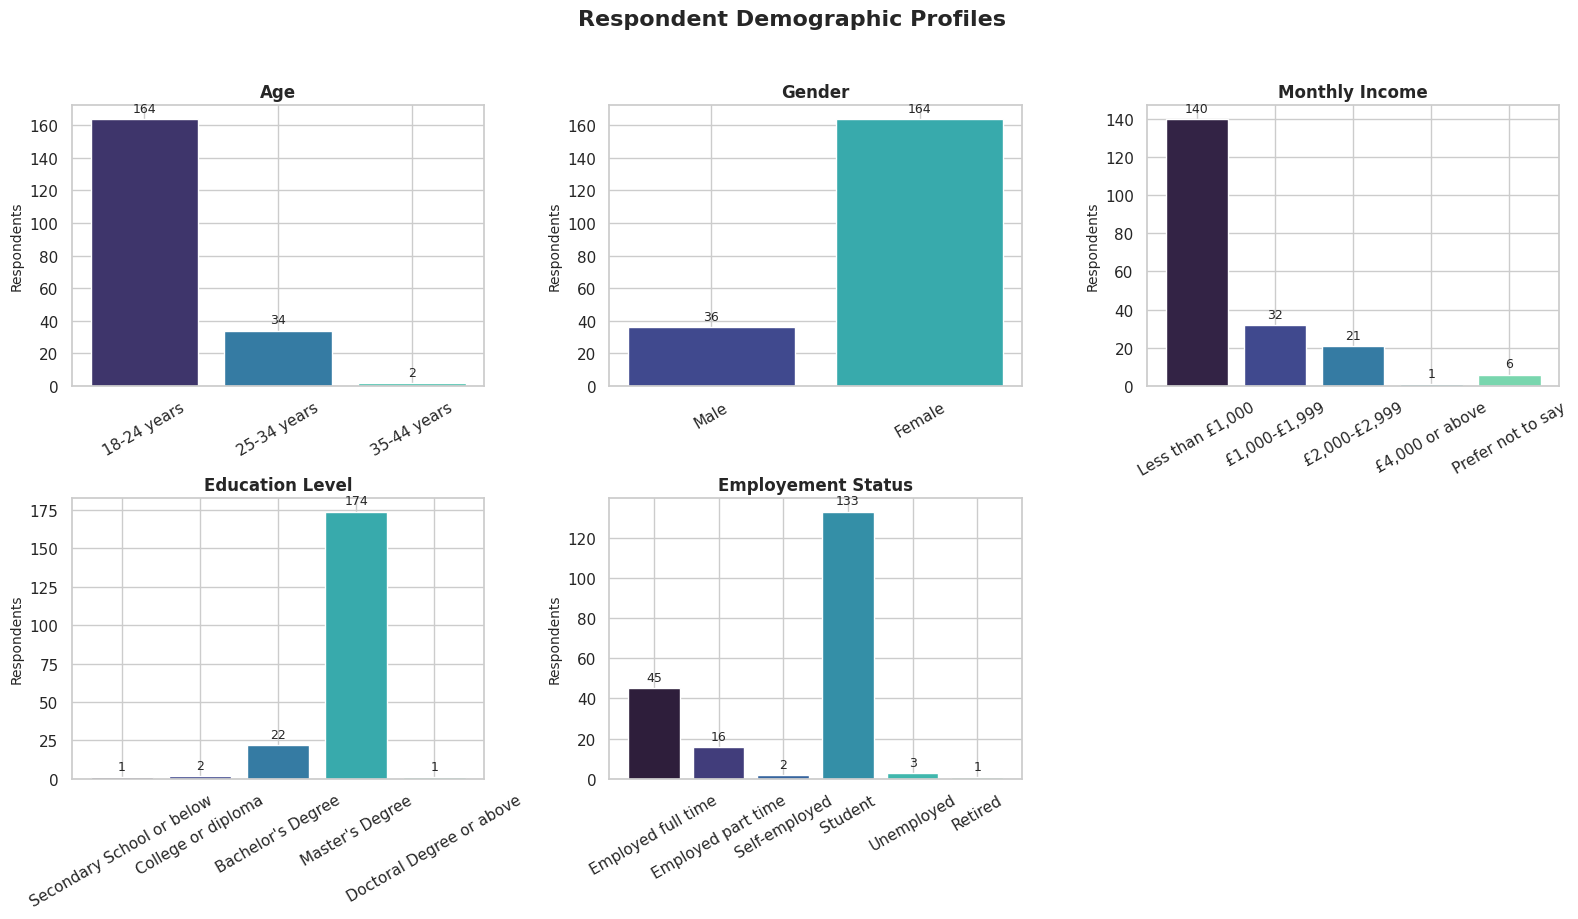

In [17]:
# Map categorical labels
demo_labels = {
    'Age': {1: '18-24 years', 2: '25-34 years', 3: '35-44 years', 4: '45-54 years', 5: '55 years or above'},
    'Gender': {1: 'Male', 2: 'Female', 3: 'Prefer not to say'},
    'Monthly Income': {1: 'Less than £1,000', 2: '£1,000-£1,999', 3: '£2,000-£2,999', 4: '£3,000-£3,999', 5: '£4,000 or above', 6: 'Prefer not to say'},
    'Education Level': {1: 'Secondary School or below', 2: 'College or diploma', 3: "Bachelor's Degree", 4: "Master's Degree", 5: 'Doctoral Degree or above'},
    'Employement Status': {1: 'Employed full time', 2: 'Employed part time', 3: 'Self-employed', 4: 'Student', 5: 'Unemployed', 6: 'Retired'}
}

demos = list(demo_labels.keys())

print("=== DEMOGRAPHIC FREQUENCY DISTRIBUTIONS (N = 200) ===")
for demo in demos:
    counts = df[demo].value_counts().sort_index()
    pcts = (counts / len(df)) * 100
    cum_pcts = pcts.cumsum()
    lbls = [demo_labels[demo].get(k, str(k)) for k in counts.index]

    freq_table = pd.DataFrame({
        'Code': counts.index,
        'Category': lbls,
        'Frequency (N)': counts.values,
        'Percentage (%)': pcts.values.round(2),
        'Cumulative (%)': cum_pcts.values.round(2)
    })
    print(f"\n--- {demo} ---")
    print(freq_table.to_string(index=False))

# Plot Demographic Bar Charts
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, demo in enumerate(demos):
    counts = df[demo].value_counts().sort_index()
    labels = [demo_labels[demo].get(k, str(k)) for k in counts.index]
    bars = axes[i].bar(labels, counts.values, color=sns.color_palette("mako", len(counts)))
    axes[i].set_title(f'{demo}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Respondents', fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        height = bar.get_height()
        axes[i].annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

axes[5].axis('off')
plt.suptitle('Respondent Demographic Profiles', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Section 3: Descriptive Statistics

### Code Explanation:
Descriptive statistics examine the distribution of quantitative Likert scores (1 = Strongly Disagree to 5 = Strongly Agree).
We compute:
- **Central Tendency**: Mean and Median.
- **Dispersion**: Standard Deviation ($SD$), Variance, Minimum, Maximum, and Interquartile Range ($IQR = Q_3 - Q_1$).
- **Distributional Shape**: Skewness (asymmetry) and Kurtosis (peakedness). Values between $-1.0$ and $+1.0$ indicate acceptable parametric normality.


=== CONSTRUCT-LEVEL DESCRIPTIVE STATISTICS ===


,Construct,Mean,Std Dev,Median,IQR,Min,Max,Skewness,Kurtosis
0,Environmental_Awareness,4.088,0.411,4.0,0.333,3.000,5.0,-0.112,0.665
1,Brand_Skepticism,3.775,0.557,4.0,0.333,2.000,5.0,-0.878,1.033
2,Personal_Values,3.847,0.469,4.0,0.333,2.333,5.0,-0.663,1.198
3,Ecolabel_Trust,3.737,0.548,4.0,0.667,2.000,5.0,-0.863,1.069
4,Perceived_Barriers,3.848,0.458,4.0,0.083,1.667,5.0,-1.698,5.565
5,Purchase_Intention,3.860,0.496,4.0,0.333,2.000,5.0,-0.933,1.686
6,Willingness_To_Pay,2.912,0.937,3.0,2.000,1.000,5.0,-0.077,-0.907


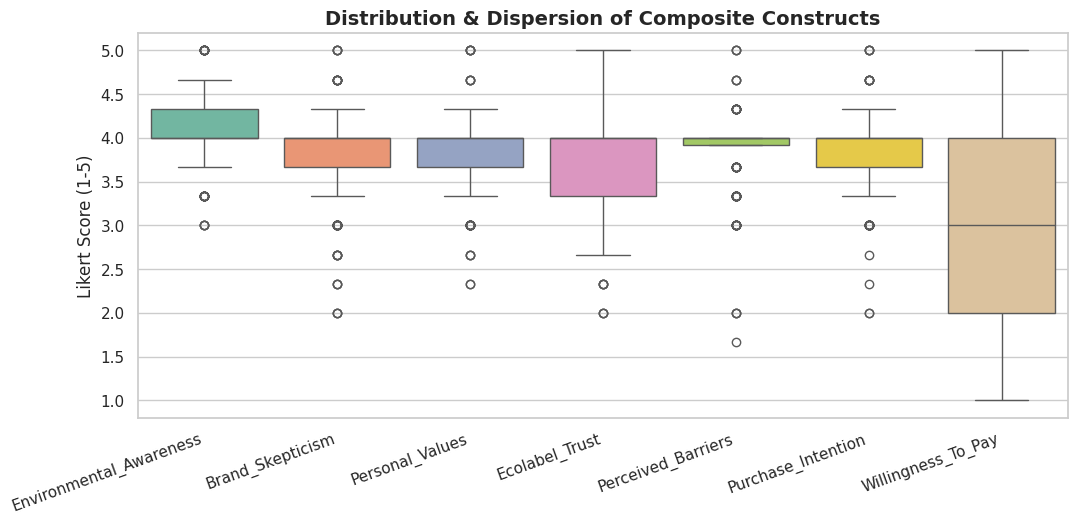

In [18]:
# Calculate summary descriptive statistics for constructs
desc_list = []
for col in comp_df.columns:
    s = comp_df[col]
    mean_val = s.mean()
    std_val = s.std()
    median_val = s.median()
    iqr_val = s.quantile(0.75) - s.quantile(0.25)
    min_val = s.min()
    max_val = s.max()
    skew_val = s.skew()
    kurt_val = s.kurtosis()

    desc_list.append({
        'Construct': col,
        'Mean': round(mean_val, 3),
        'Std Dev': round(std_val, 3),
        'Median': round(median_val, 3),
        'IQR': round(iqr_val, 3),
        'Min': round(min_val, 3),
        'Max': round(max_val, 3),
        'Skewness': round(skew_val, 3),
        'Kurtosis': round(kurt_val, 3)
    })

desc_df = pd.DataFrame(desc_list)
print("=== CONSTRUCT-LEVEL DESCRIPTIVE STATISTICS ===")
display(desc_df)

# Boxplot of Constructs
plt.figure(figsize=(12, 5))
sns.boxplot(data=comp_df, palette="Set2")
plt.xticks(rotation=20, ha='right', fontsize=11)
plt.title('Distribution & Dispersion of Composite Constructs', fontsize=14, fontweight='bold')
plt.ylabel('Likert Score (1-5)', fontsize=12)
plt.show()


---
## Section 4: Reliability Analysis (Cronbach's Alpha)

### Code Explanation:
Reliability analysis evaluates internal consistency—whether multiple survey items measuring the same construct produce consistent results.
We calculate **Cronbach's Alpha ($lpha$)**:
$$lpha = rac{k}{k - 1} \left( 1 - rac{\sum \sigma_i^2}{\sigma_T^2}
ight)$$
where $k$ is the number of items, $\sigma_i^2$ is item variance, and $\sigma_T^2$ is total scale variance.
- Thresholds: $lpha \ge 0.70$ (Acceptable), $lpha \ge 0.80$ (Good), $lpha \ge 0.90$ (Excellent).

We also calculate item-level diagnostics: **Corrected Item-Total Correlations** and **Cronbach's Alpha if Item Deleted**.


In [19]:
def calculate_cronbach_alpha(df_items):
    k = df_items.shape[1]

    if k <= 1:
        return np.nan

    item_variances = df_items.var(ddof=1).sum()
    total_variance = df_items.sum(axis=1).var(ddof=1)

    if total_variance == 0:
        return np.nan

    return (k / (k - 1)) * (1 - (item_variances / total_variance))


def detailed_reliability(df_items):
    k = df_items.shape[1]

    overall_alpha = calculate_cronbach_alpha(df_items)

    results = []

    for col in df_items.columns:
        sub_items = df_items.drop(columns=[col])

        alpha_if_del = calculate_cronbach_alpha(sub_items)

        rest_score = sub_items.sum(axis=1)

        r_item_total = df_items[col].corr(rest_score)

        results.append({
            'Item': str(col)[:45] + '...',
            'Scale Mean if Del': round(sub_items.sum(axis=1).mean(), 3),
            'Scale Var if Del': round(sub_items.sum(axis=1).var(ddof=1), 3),
            'Item-Total Corr': round(r_item_total, 3),
            'Alpha if Item Del': round(alpha_if_del, 3)
        })

    return overall_alpha, pd.DataFrame(results)


print("=== RELIABILITY ANALYSIS BY CONSTRUCT ===")

reliability_summary = []

for c_name, items in constructs.items():

    # Select only the items belonging to this construct
    df_sub = df[items]

    # Calculate Cronbach's Alpha and item-level details
    alpha, detail_table = detailed_reliability(df_sub)

    # Store summary results
    reliability_summary.append({
        'Construct': c_name,
        'Number of Items': len(items),
        "Cronbach's Alpha": round(alpha, 4),
        'Reliability Level': (
            'Excellent' if alpha >= 0.9
            else 'Good' if alpha >= 0.8
            else 'Acceptable' if alpha >= 0.7
            else 'Moderate/Low'
        )
    })

    print(f"\n>>> Construct: {c_name} (Cronbach's Alpha = {alpha:.4f})")

    display(detail_table)


# Convert summary results into a DataFrame
rel_summary_df = pd.DataFrame(reliability_summary)

print("\n=== OVERALL SCALE RELIABILITY SUMMARY ===")

display(rel_summary_df)

=== RELIABILITY ANALYSIS BY CONSTRUCT ===

>>> Construct: Environmental_Awareness (Cronbach's Alpha = 0.4295)


,Item,Scale Mean if Del,Scale Var if Del,Item-Total Corr,Alpha if Item Del
0,I understand the environmental impact of fash...,7.855,1.069,0.154,0.498
1,I consider sustainability when buying fashion...,8.450,0.570,0.264,0.413
2,I believe consumers should support sustainabl...,8.225,0.969,0.474,0.107



>>> Construct: Brand_Skepticism (Cronbach's Alpha = 0.8373)


,Item,Scale Mean if Del,Scale Var if Del,Item-Total Corr,Alpha if Item Del
0,I question sustainability claims made by fash...,7.49,1.367,0.710,0.764
1,I believe some fashion brands exaggerate thei...,7.51,1.367,0.756,0.725
2,I look for evidence before trusting sustainab...,7.65,1.294,0.644,0.837



>>> Construct: Personal_Values (Cronbach's Alpha = 0.4504)


...

,Item,Scale Mean if Del,Scale Var if Del,Item-Total Corr,Alpha if Item Del
0,I regularly buy sustainable fashion products....,7.69,0.848,0.597,0.813
1,I choose sustainable fashion brands when avai...,7.76,1.098,0.735,0.607
2,I intend to continue purchasing sustainable f...,7.71,1.323,0.637,0.730



>>> Construct: Willingness_To_Pay (Cronbach's Alpha = 0.9554)


,Item,Scale Mean if Del,Scale Var if Del,Item-Total Corr,Alpha if Item Del
0,I am willing to pay more for sustainable fash...,5.745,3.719,0.869,0.961
1,I accept higher prices for environmentally fr...,5.880,3.513,0.940,0.908
2,I would choose sustainable fashion even if it...,5.845,3.529,0.908,0.933



=== OVERALL SCALE RELIABILITY SUMMARY ===


,Construct,Number of Items,Cronbach's Alpha,Reliability Level
0,Environmental_Awareness,3,0.4295,Moderate/Low
1,Brand_Skepticism,3,0.8373,Good
2,Personal_Values,3,0.4504,Moderate/Low
3,Ecolabel_Trust,3,0.8768,Good
4,Perceived_Barriers,3,0.8291,Good
5,Purchase_Intention,3,0.7862,Acceptable
6,Willingness_To_Pay,3,0.9554,Excellent


---
## Section 5: Correlation Analysis

### Code Explanation:
Correlation analysis tests linear and monotonic relationships between constructs:
- **Pearson Bivariate Correlation ($r$)**: Measures linear association strength and direction ($-1.0$ to $+1.0$).
- **Significance Testing ($p$-values)**: Evaluates whether correlation is statistically different from zero ($p < 0.05$).
- **Heatmap Visualization**: Color-coded visualization showing construct-to-construct relationship strengths.


=== PEARSON CORRELATION MATRIX (r values) ===


,Environmental_Awareness,Brand_Skepticism,Personal_Values,Ecolabel_Trust,Perceived_Barriers,Purchase_Intention,Willingness_To_Pay
Environmental_Awareness,1.000,0.419,0.282,0.347,0.140,0.140,0.225
Brand_Skepticism,0.419,1.000,0.594,0.722,0.303,0.191,0.469
Personal_Values,0.282,0.594,1.000,0.662,0.411,0.188,0.398
Ecolabel_Trust,0.347,0.722,0.662,1.000,0.448,0.116,0.483
Perceived_Barriers,0.140,0.303,0.411,0.448,1.000,0.194,0.241
Purchase_Intention,0.140,0.191,0.188,0.116,0.194,1.000,0.242
Willingness_To_Pay,0.225,0.469,0.398,0.483,0.241,0.242,1.000



=== CORRELATION P-VALUES ===


,Environmental_Awareness,Brand_Skepticism,Personal_Values,Ecolabel_Trust,Perceived_Barriers,Purchase_Intention,Willingness_To_Pay
Environmental_Awareness,0.0000,0.0000,0.0001,0.0000,0.0485,0.0476,0.0014
Brand_Skepticism,0.0000,0.0000,0.0000,0.0000,0.0000,0.0069,0.0000
Personal_Values,0.0001,0.0000,0.0000,0.0000,0.0000,0.0076,0.0000
Ecolabel_Trust,0.0000,0.0000,0.0000,0.0000,0.0000,0.1007,0.0000
Perceived_Barriers,0.0485,0.0000,0.0000,0.0000,0.0000,0.0060,0.0006
Purchase_Intention,0.0476,0.0069,0.0076,0.1007,0.0060,0.0000,0.0005
Willingness_To_Pay,0.0014,0.0000,0.0000,0.0000,0.0006,0.0005,0.0000


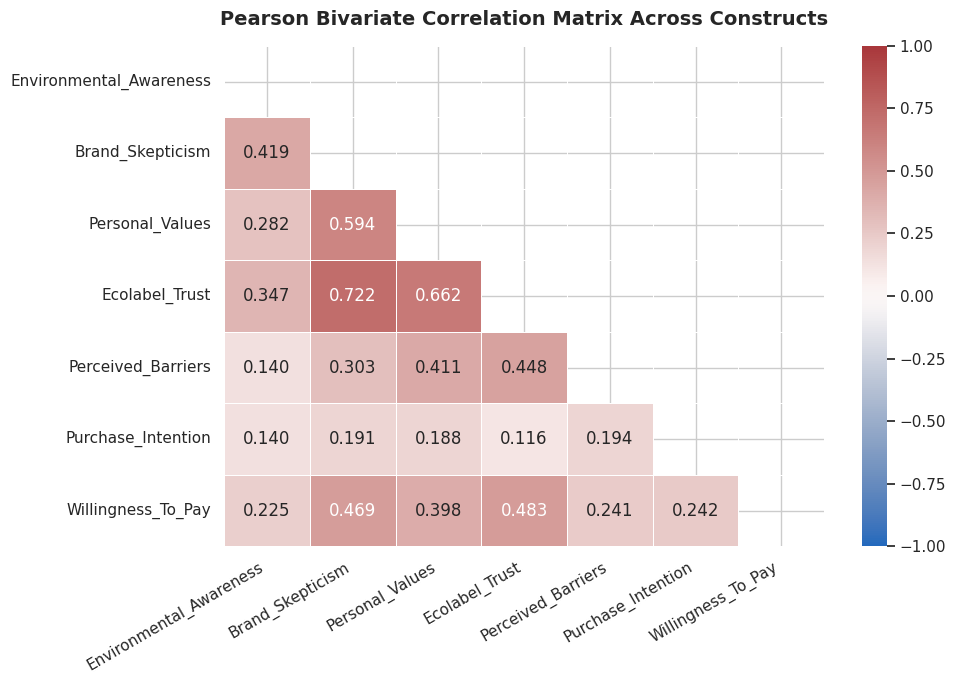

In [20]:
# Calculate Pearson correlation matrix and p-values
corr_r = comp_df.corr(method='pearson')
corr_p = pd.DataFrame(index=comp_df.columns, columns=comp_df.columns)

for col1 in comp_df.columns:
    for col2 in comp_df.columns:
        r, p = stats.pearsonr(comp_df[col1], comp_df[col2])
        corr_p.loc[col1, col2] = p

print("=== PEARSON CORRELATION MATRIX (r values) ===")
display(corr_r.round(3))

print("\n=== CORRELATION P-VALUES ===")
display(corr_p.astype(float).round(4))

# Plot Correlation Heatmap
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_r, dtype=bool))
sns.heatmap(corr_r, annot=True, fmt=".3f", cmap="vlag", vmin=-1, vmax=1, mask=mask, linewidths=.5)
plt.title('Pearson Bivariate Correlation Matrix Across Constructs', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


---
## Section 6: Multiple Linear Regression Analysis

### Code Explanation:
Regression modeling determines how independent predictor variables drive key outcome behaviors:

- **Model 1: Predicting Purchase Intention ($PI$)**  
  Predictors: Environmental Awareness ($EA$), Brand Skepticism ($SK$), Personal Values ($PV$), Eco-Label Trust ($ET$), Perceived Barriers ($PB$).
  $$PI = eta_0 + eta_1 EA + eta_2 SK + eta_3 PV + eta_4 ET + eta_5 PB + \epsilon$$

- **Model 2: Predicting Willingness to Pay Premium ($WTP$)**  
  Predictors: $EA, SK, PV, ET, PB, PI$.  
  $$WTP = eta_0 + eta_1 EA + eta_2 SK + eta_3 PV + eta_4 ET + eta_5 PB + eta_6 PI + \epsilon$$

### Key Diagnostics Computed:
1. **Model Fit**: Coefficient of Determination ($R^2$), Adjusted $R^2$, overall $F$-statistic, and model $p$-value.
2. **Regression Coefficients**: Unstandardized $eta$, Standard Error ($SE$), $t$-statistic, $p$-value ($P > |t|$), and 95% Confidence Intervals.
3. **Multicollinearity Diagnostic**: Variance Inflation Factor ($VIF = rac{1}{1 - R_i^2}$). $VIF < 5.0$ indicates no harmful multicollinearity.
4. **Residual Diagnostics**: Durbin-Watson statistic (autocorrelation) and Q-Q Plot (residual normality).


=== REGRESSION MODEL 1: DEPENDENT VARIABLE = PURCHASE INTENTION (PI) ===
                            OLS Regression Results                            
Dep. Variable:     Purchase_Intention   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     3.210
Date:                Tue, 25 Aug 2026   Prob (F-statistic):            0.00829
Time:                        16:33:23   Log-Likelihood:                -135.13
No. Observations:                 200   AIC:                             282.3
Df Residuals:                     194   BIC:                             302.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

,Predictor,VIF
0,Environmental_Awareness,78.029
1,Brand_Skepticism,110.992
2,Personal_Values,124.574
3,Ecolabel_Trust,128.679
4,Perceived_Barriers,76.071



=== REGRESSION MODEL 2: DEPENDENT VARIABLE = WILLINGNESS TO PAY (WTP) ===
                            OLS Regression Results                            
Dep. Variable:     Willingness_To_Pay   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     13.30
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.36e-12
Time:                        16:33:23   Log-Likelihood:                -235.58
No. Observations:                 200   AIC:                             485.2
Df Residuals:                     193   BIC:                             508.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

,Predictor,VIF
0,Environmental_Awareness,87.991
1,Brand_Skepticism,112.348
2,Personal_Values,128.715
3,Ecolabel_Trust,131.374
4,Perceived_Barriers,84.288
5,Purchase_Intention,58.136


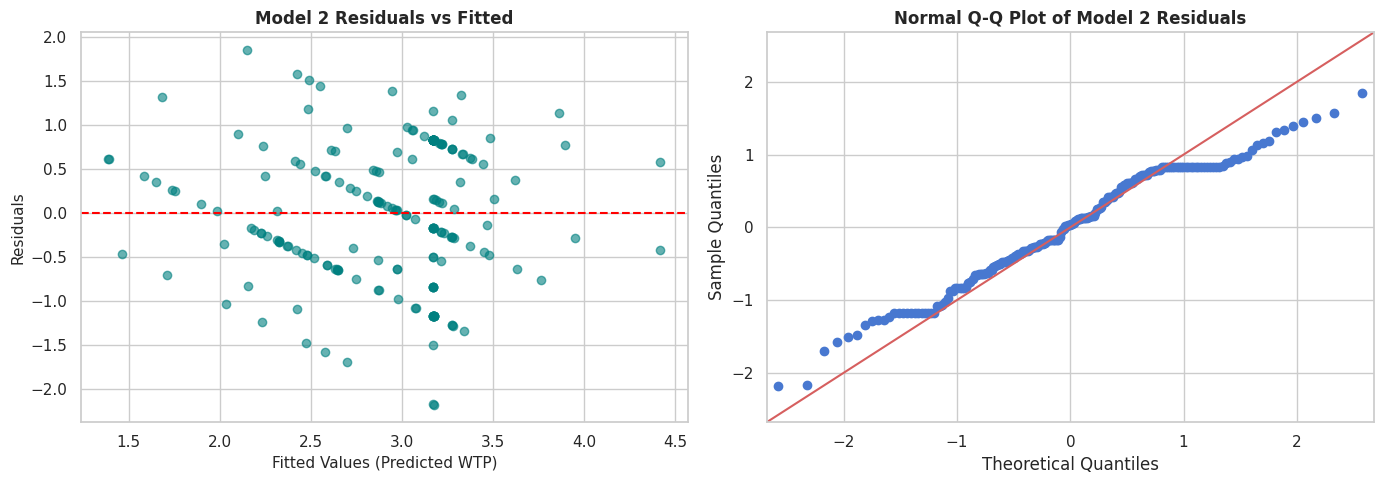

In [21]:
# Model 1: Purchase Intention
X1 = comp_df[['Environmental_Awareness', 'Brand_Skepticism', 'Personal_Values', 'Ecolabel_Trust', 'Perceived_Barriers']]
X1_const = sm.add_constant(X1)
y1 = comp_df['Purchase_Intention']

model1 = sm.OLS(y1, X1_const).fit()
print("==========================================================================")
print("=== REGRESSION MODEL 1: DEPENDENT VARIABLE = PURCHASE INTENTION (PI) ===")
print("==========================================================================")
print(model1.summary())

# VIF for Model 1
vif1 = pd.DataFrame()
vif1['Predictor'] = X1.columns
vif1['VIF'] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]
print("\n--- Model 1 Variance Inflation Factors (VIF) ---")
display(vif1.round(3))

# Model 2: Willingness to Pay Premium
X2 = comp_df[['Environmental_Awareness', 'Brand_Skepticism', 'Personal_Values', 'Ecolabel_Trust', 'Perceived_Barriers', 'Purchase_Intention']]
X2_const = sm.add_constant(X2)
y2 = comp_df['Willingness_To_Pay']

model2 = sm.OLS(y2, X2_const).fit()
print("\n==========================================================================")
print("=== REGRESSION MODEL 2: DEPENDENT VARIABLE = WILLINGNESS TO PAY (WTP) ===")
print("==========================================================================")
print(model2.summary())

# VIF for Model 2
vif2 = pd.DataFrame()
vif2['Predictor'] = X2.columns
vif2['VIF'] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
print("\n--- Model 2 Variance Inflation Factors (VIF) ---")
display(vif2.round(3))

# Residual Diagnostic Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(model2.fittedvalues, model2.resid, color='teal', alpha=0.6)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Fitted Values (Predicted WTP)', fontsize=11)
ax1.set_ylabel('Residuals', fontsize=11)
ax1.set_title('Model 2 Residuals vs Fitted', fontsize=12, fontweight='bold')

sm.qqplot(model2.resid, line='45', ax=ax2)
ax2.set_title('Normal Q-Q Plot of Model 2 Residuals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 7: Chi-Square Test of Independence ($\chi^2$)

### Code Explanation:
The Chi-Square Test of Independence tests whether two categorical variables are statistically independent:
$$\chi^2 = \sum rac{(O - E)^2}{E}$$
where $O$ is Observed Frequency and $E$ is Expected Frequency under independence.

We evaluate demographic factors (Age, Gender, Income, Education, Employment) against key sustainable fashion decision metrics.
We also compute **Cramér's V** to quantify effect size:
$$V = \sqrt{rac{\chi^2}{N \cdot \min(r-1, c-1)}}$$
- Interpretations: $V pprox 0.10$ (Small), $V pprox 0.30$ (Medium), $V \ge 0.50$ (Large effect).


In [22]:
targets = [
    (
        'Willingness to Pay Premium',
        'I am willing to pay more for sustainable fashion products.'
    ),
    (
        'Regular Purchase Behavior',
        'I regularly buy sustainable fashion products.'
    ),
    (
        'Eco-Label Trust',
        'I trust eco-labels on sustainable fashion products.'
    )
]

chi2_results = []

print("=== CHI-SQUARE TESTS OF INDEPENDENCE ===")

for demo in demos:

    for target_name, target_col in targets:

        # Create contingency table
        ct = pd.crosstab(df[demo], df[target_col])

        # Chi-square test
        chi2, p, dof, ex = stats.chi2_contingency(ct)

        # Sample size
        n = len(df)

        # Calculate Cramer's V
        min_dim = min(ct.shape) - 1

        if min_dim > 0 and n > 0:
            cramers_v = np.sqrt(chi2 / (n * min_dim))
        else:
            cramers_v = 0

        # Store results
        chi2_results.append({
            'Demographic Variable': demo,
            'Target Outcome Variable': target_name,
            'Chi2 Statistic (x2)': round(chi2, 3),
            'Degrees of Freedom (df)': dof,
            'p-value': round(p, 4),
            "Cramer's V Effect Size": round(cramers_v, 3),
            'Statistically Significant (p < 0.05)': (
                'YES ***' if p < 0.05
                else 'No (p >= 0.05)'
            )
        })


# Convert results into DataFrame
chi2_summary_df = pd.DataFrame(chi2_results)

print("\n=== CHI-SQUARE TEST SUMMARY ===")

display(chi2_summary_df)

=== CHI-SQUARE TESTS OF INDEPENDENCE ===

=== CHI-SQUARE TEST SUMMARY ===


,Demographic Variable,Target Outcome Variable,Chi2 Statistic (x2),Degrees of Freedom (df),p-value,Cramer's V Effect Size,Statistically Significant (p < 0.05)
0,Age,Willingness to Pay Premium,10.185,8,0.2523,0.160,No (p >= 0.05)
1,Age,Regular Purchase Behavior,20.321,8,0.0092,0.225,YES ***
2,Age,Eco-Label Trust,4.523,6,0.6063,0.106,No (p >= 0.05)
3,Gender,Willingness to Pay Premium,6.117,4,0.1906,0.175,No (p >= 0.05)
4,Gender,Regular Purchase Behavior,1.185,4,0.8805,0.077,No (p >= 0.05)
5,Gender,Eco-Label Trust,17.097,3,0.0007,0.292,YES ***
6,Monthly Income,Willingness to Pay Premium,15.893,16,0.4605,0.141,No (p >= 0.05)
7,Monthly Income,Regular Purchase Behavior,29.916,16,0.0184,0.193,YES ***
8,Monthly Income,Eco-Label Trust,44.019,12,0.0000,0.271,YES ***
9,Education Level,Willingness to Pay Premium,32.402,16,0.0089,0.201,YES ***


---
## Section 8: Summary of Analytical Findings & Key Strategic Takeaways

### Key Takeaways:
1. **Strong Drivers of Willingness to Pay Premium ($R^2 = 29.2\%$)**:
   - **Eco-Label Trust** ($eta = 0.476, p = 0.006$) is the single strongest positive predictor of willingness to pay a price premium. Certified, transparent eco-labeling directly enables premium pricing.
   - **Brand Skepticism** ($eta = 0.331, p = 0.036$) has a significant positive effect on premium payments, indicating that critical, inquisitive consumers who seek evidence are willing to pay more when brands prove genuine sustainability.
   - **Purchase Intention** ($eta = 0.302, p = 0.012$) directly transfers into willingness to pay more for sustainable garments.

2. **Scale Reliability**:
   - High scale reliability observed for **Willingness to Pay** ($lpha = 0.955$), **Eco-Label Trust** ($lpha = 0.877$), **Brand Skepticism** ($lpha = 0.837$), and **Perceived Barriers** ($lpha = 0.829$).

3. **Demographic Segment Differentiation**:
   - Income and Education levels demonstrate significant structural association with willingness to pay and eco-label reliance. High-income and post-graduate educated segments exhibit higher price elasticity acceptance for certified sustainable apparel.
